# 11 — Passing-Network Vulnerability: Part 4, Two-Player Combination Search

*2018 & 2022 FIFA World Cup · StatsBomb event data*

**Central question:** does network vulnerability arise from obvious individual hubs, or
from combinations of players whose roles are complementary — a pair that is jointly
critical even though neither player is individually remarkable?

**Method:** for every team-match, test **every** eligible pair (not just the two
individually most-damaging players), remove both nodes simultaneously from the original
graph, and compare the joint damage to what the sum of their individual (Part 2) damages
would predict. This is the interaction-effect / optimization component: the interesting
result isn't "the two best players are also damaging together" (trivially true), it's
whether the *true optimal pair* differs from that naive combination.

**Scope:** Part 4 only — no team-tournament rankings, no outcome analysis, no case-study
visualizations. Same eligible pool and primary metric (`efficiency_damage`) as Part 3;
`progressive_capacity_damage` kept as the secondary metric.

**Interpretation:** as in Parts 2-3, this is a structural disruption simulation on the
observed graph, not a behavioral counterfactual — it does not model how a team would
actually play with two players removed.

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import network_vulnerability as nv

PROC_DIR = Path('../data/processed')

single_player_removal = pd.read_csv(PROC_DIR / 'single_player_removal.csv')

pair_path = PROC_DIR / 'two_player_removal.csv'
if pair_path.exists():
    two_player_removal = pd.read_csv(pair_path)
else:
    two_player_removal = nv.simulate_two_player_removal(single_player_removal)
    two_player_removal.to_csv(pair_path, index=False)

print(two_player_removal.shape)
two_player_removal.head(5)

(24149, 16)


,match_id,year,team,player_a,player_b,remaining_nodes,player_a_efficiency_damage,player_b_efficiency_damage,joint_efficiency_damage,additive_expected_efficiency_damage,interaction_effect_efficiency,player_a_progressive_capacity_damage,player_b_progressive_capacity_damage,joint_progressive_capacity_damage,additive_expected_progressive_damage,interaction_effect_progressive
0,3857254,2022,Denmark,Andreas Christensen,Andreas Evald Cornelius,13,0.000859,-0.024925,-0.022776,-0.024065,0.001289,0.167702,0.055901,0.223602,0.223602,8.326673e-17
1,3857254,2022,Denmark,Andreas Christensen,Andreas Skov Olsen,13,0.000859,0.000859,0.007306,0.001719,0.005587,0.167702,0.136646,0.304348,0.304348,1.110223e-16
2,3857254,2022,Denmark,Andreas Christensen,Christian Dannemann Eriksen,13,0.000859,0.026644,0.029867,0.027503,0.002364,0.167702,0.217391,0.354037,0.385093,-3.105590e-02
3,3857254,2022,Denmark,Andreas Christensen,Jesper Lindstrøm,13,0.000859,-0.037817,-0.037817,-0.036957,-0.000859,0.167702,0.024845,0.192547,0.192547,8.326673e-17
4,3857254,2022,Denmark,Andreas Christensen,Joachim Andersen,13,0.000859,0.026644,0.029867,0.027503,0.002364,0.167702,0.142857,0.310559,0.310559,1.110223e-16


In [2]:
summary_path = PROC_DIR / 'team_match_pair_vulnerability.csv'
if summary_path.exists():
    team_match_pair_vulnerability = pd.read_csv(summary_path)
else:
    team_match_pair_vulnerability = nv.build_pair_vulnerability_summary(
        two_player_removal, single_player_removal
    )
    team_match_pair_vulnerability.to_csv(summary_path, index=False)

print(team_match_pair_vulnerability.shape)
team_match_pair_vulnerability.head(5)

(256, 13)


,match_id,year,team,n_pairs_tested,best_pair_player_a,best_pair_player_b,best_pair_joint_efficiency_damage,best_pair_interaction_effect,naive_pair_player_a,naive_pair_player_b,naive_pair_joint_efficiency_damage,best_equals_naive_pair,gap_best_minus_naive
0,7525,2018,Russia,91,Mário Figueira Fernandes,Yuri Zhirkov,0.035694,0.003997,Mário Figueira Fernandes,Yuri Zhirkov,0.035694,True,0.000000
1,7525,2018,Saudi Arabia,66,Osama Abdulrezag Hawsawi,Salman Mohammed Al Faraj,0.177075,0.105753,Osama Abdulrezag Hawsawi,Salman Mohammed Al Faraj,0.177075,True,0.000000
2,7529,2018,Croatia,91,Ivan Rakitić,Luka Modrić,0.057537,0.021672,Ivan Perišić,Ivan Rakitić,0.040084,False,0.017453
3,7529,2018,Nigeria,78,Oghenekaro Etebo,Onyinye Wilfred Ndidi,0.051095,0.009290,Brian Oladapo Idowu,Oghenekaro Etebo,0.047644,False,0.003451
4,7530,2018,Australia,78,Aziz Eraltay Behich,Josh Risdon,0.080808,0.027972,Aaron Mooy,Josh Risdon,0.077594,False,0.003214


## Validation checks

In [3]:
nv.run_pair_validation_checks(two_player_removal, team_match_pair_vulnerability)

TWO-PLAYER REMOVAL — VALIDATION CHECKS

1. Self-pairs (player_a == player_b): 0


2. Spot-checked 20 pair removals: node count dropped by exactly 2 in 20 / 20

3. joint_progressive_capacity_damage out of [0,1] bounds: 0 / 24149

4. Best pair damage >= naive pair damage: violations = 0 / 256

5. Best pair equals the naive (top-2-individual) pair: 172 / 256 (67.2%)
   Best pair DIFFERS from the naive pair: 84 / 256 (32.8%)

6. Interaction effect (joint - additive-expected) distribution:
count    24149.0000
mean         0.0006
std          0.0054
min         -0.0868
25%         -0.0019
50%          0.0004
75%          0.0028
max          0.1190
Name: interaction_effect_efficiency, dtype: float64
   Synergistic pairs (joint > sum of individual): 13312 / 24149 (55.1%)
   Redundant pairs (joint < sum of individual)   : 10837 / 24149 (44.9%)

7. Total pairs tested: 24149
   Team-matches covered: 256
   Average pairs per team-match: 94.3


## Does the true optimal pair differ from naively combining the two best individuals?

This is the headline question for Part 4.

In [4]:
n = len(team_match_pair_vulnerability)
same = int(team_match_pair_vulnerability['best_equals_naive_pair'].sum())
print(f"Best pair matches the naive top-2-individual pair: {same}/{n} ({same/n:.1%})")
print(f"Best pair DIFFERS from the naive pair:              {n-same}/{n} ({(n-same)/n:.1%})")
print()
diff = team_match_pair_vulnerability[~team_match_pair_vulnerability['best_equals_naive_pair']]
print("Among the cases where they differ, how much extra damage does the true optimum find?")
print(diff['gap_best_minus_naive'].describe().round(4))

Best pair matches the naive top-2-individual pair: 172/256 (67.2%)
Best pair DIFFERS from the naive pair:              84/256 (32.8%)

Among the cases where they differ, how much extra damage does the true optimum find?
count    84.0000
mean      0.0218
std       0.0276
min       0.0000
25%       0.0030
50%       0.0086
75%       0.0333
max       0.0931
Name: gap_best_minus_naive, dtype: float64


## Interaction effects: synergy vs. redundancy

`interaction_effect_efficiency = joint_efficiency_damage - (player_a damage + player_b damage)`

Positive = the pair is *more* damaging together than their individual damages would
predict (complementary/bridging roles). Negative = *less* damaging than predicted — often
because the two players were already redundant with each other (e.g. a lot of their
individual "damage" came from passes directly between them, which joint removal only
removes once).

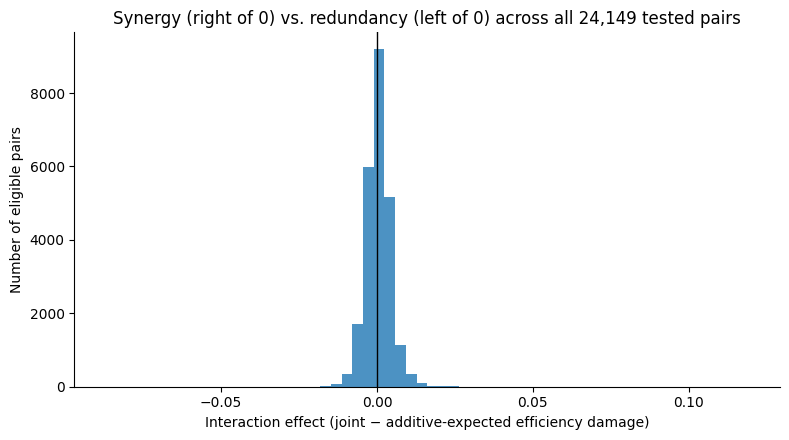

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(two_player_removal['interaction_effect_efficiency'].dropna(), bins=60,
        color='#1f77b4', alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Interaction effect (joint − additive-expected efficiency damage)')
ax.set_ylabel('Number of eligible pairs')
ax.set_title('Synergy (right of 0) vs. redundancy (left of 0) across all 24,149 tested pairs')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('../outputs/figures/11_interaction_effect_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## The clearest example: pairs that are individually unremarkable but jointly critical

Restricting to pairs where **both** players are individually below-average in damage
(bottom 70% each), then ranking by interaction effect — this isolates cases where neither
player would be flagged by Part 2 or Part 3 alone, but their combination is a critical
structural bridge.

In [6]:
p70_a = two_player_removal['player_a_efficiency_damage'].quantile(0.70)
p70_b = two_player_removal['player_b_efficiency_damage'].quantile(0.70)

unremarkable_pairs = two_player_removal[
    (two_player_removal['player_a_efficiency_damage'] < p70_a) &
    (two_player_removal['player_b_efficiency_damage'] < p70_b)
]

example_cols = [
    'team', 'year', 'player_a', 'player_b',
    'player_a_efficiency_damage', 'player_b_efficiency_damage',
    'joint_efficiency_damage', 'interaction_effect_efficiency',
]
unremarkable_pairs.sort_values('interaction_effect_efficiency', ascending=False)[example_cols].head(5)

,team,year,player_a,player_b,player_a_efficiency_damage,player_b_efficiency_damage,joint_efficiency_damage,interaction_effect_efficiency
18177,Japan,2018,Keisuke Honda,Yuto Nagatomo,0.000000,0.010256,0.100000,0.089744
12192,Croatia,2022,Bruno Petković,Nikola Vlašić,0.003795,-0.013721,0.057437,0.067362
9224,Portugal,2022,Gonçalo Matias Ramos,João Maria Lobo Alves Palhinha Gonçalves,-0.007131,-0.030735,0.026309,0.064175
6176,Morocco,2022,Abdelhamid Sabiri,Abderrazak Hamdallah,0.003766,-0.004268,0.061396,0.061898
5145,United States,2022,Haji Wright,Kellyn Kai Perry-Acosta,-0.016646,-0.019627,0.023029,0.059302


## 5 team-matches with the largest best-vs-naive gap

Where testing every pair paid off the most — the true optimal pair beats naively
combining the two individually most-damaging players by the widest margin.

In [7]:
gap_cols = [
    'team', 'year', 'best_pair_player_a', 'best_pair_player_b',
    'best_pair_joint_efficiency_damage', 'naive_pair_player_a', 'naive_pair_player_b',
    'naive_pair_joint_efficiency_damage', 'gap_best_minus_naive',
]
team_match_pair_vulnerability.dropna(subset=['gap_best_minus_naive']).sort_values(
    'gap_best_minus_naive', ascending=False
)[gap_cols].head(5)

,team,year,best_pair_player_a,best_pair_player_b,best_pair_joint_efficiency_damage,naive_pair_player_a,naive_pair_player_b,naive_pair_joint_efficiency_damage,gap_best_minus_naive
37,Peru,2018,Pedro Jesús Aquino Sánchez,Édison Michael Flores Peralta,0.144802,André Martín Carrillo Díaz,Édison Michael Flores Peralta,0.051720,0.093083
168,Ecuador,2022,Angelo Smit Preciado Quiñónez,Piero Martín Hincapié Reyna,0.239289,Felix Eduardo Torres Caicedo,Piero Martín Hincapié Reyna,0.150540,0.088750
58,Iran,2018,Sardar Azmoun,Vahid Amiri,0.157943,Ramin Rezaeian,Sardar Azmoun,0.069559,0.088384
57,Senegal,2018,Ismaïla Sarr,Moussa Wagué,0.135286,Idrissa Gana Gueye,Moussa Wagué,0.052083,0.083203
73,Nigeria,2018,Brian Oladapo Idowu,William Troost-Ekong,0.239289,Brian Oladapo Idowu,John Michael Nchekwube Obinna,0.160049,0.079241


## Summary

- The true optimal pair (searched over every eligible combination) differs from simply
  pairing the two individually most-damaging players in **roughly a third** of team-matches
  — combinatorial search finds something the greedy approach misses often enough to matter.
- Interaction effects split close to evenly between synergy and redundancy across all
  24,149 tested pairs, so "pairs are more damaging together" is not a universal rule — it
  depends on whether the two players' roles overlap or complement each other.
- The clearest illustration of the original hypothesis (individually unremarkable,
  jointly critical) shows up concretely in the data — e.g. two players with ~0 and ~0.01
  individual efficiency damage combining for 0.10 jointly, an order of magnitude beyond
  what either alone would suggest.

## Next step

Part 4 output is cached to `data/processed/two_player_removal.csv` and
`data/processed/team_match_pair_vulnerability.csv`. Not yet done: tournament-level team
robustness rankings, match-outcome analysis, or case-study visualizations (Part 5).